dự đoán c02


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/BTL_hocmay/fuel.csv')

/tmp/ipykernel_576/2129353085.py:1: DtypeWarning: Columns (7,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('drive/MyDrive/Colab Notebooks/BTL_hocmay/fuel.csv')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [ ]:
df.shape

(38113, 81)

In [ ]:
df.head()

,vehicle_id,year,make,model,class,drive,transmission,transmission_type,engine_index,engine_descriptor,...,hours_to_charge_ac_240v,composite_city_mpg,composite_highway_mpg,composite_combined_mpg,range_ft1,city_range_ft1,highway_range_ft1,range_ft2,city_range_ft2,highway_range_ft2
0,26587,1984,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,Manual 5-Speed,NaN,9001,(FFS),...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
1,27705,1984,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,Manual 5-Speed,NaN,9005,(FFS) CA model,...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
2,26561,1984,Alfa Romeo,Spider Veloce 2000,Two Seaters,NaN,Manual 5-Speed,NaN,9002,(FFS),...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
3,27681,1984,Alfa Romeo,Spider Veloce 2000,Two Seaters,NaN,Manual 5-Speed,NaN,9006,(FFS) CA model,...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
4,27550,1984,AM General,DJ Po Vehicle 2WD,Special Purpose Vehicle 2WD,2-Wheel Drive,Automatic 3-Speed,NaN,1830,(FFS),...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0


In [ ]:
# Xem thông tin dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38113 entries, 0 to 38112
Data columns (total 81 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   vehicle_id                         38113 non-null  int64  
 1   year                               38113 non-null  int64  
 2   make                               38113 non-null  object 
 3   model                              38113 non-null  object 
 4   class                              38113 non-null  object 
 5   drive                              36924 non-null  object 
 6   transmission                       38102 non-null  object 
 7   transmission_type                  15045 non-null  object 
 8   engine_index                       38113 non-null  int64  
 9   engine_descriptor                  22693 non-null  object 
 10  engine_cylinders                   37977 non-null  float64
 11  engine_displacement                37979 non-null  flo

In [ ]:
# Thống kê mô tả dữ liệu số
df.describe()

,vehicle_id,year,engine_index,engine_cylinders,engine_displacement,supercharger,fuel_type_2,city_mpg_ft1,unrounded_city_mpg_ft1,city_mpg_ft2,...,hours_to_charge_ac_240v,composite_city_mpg,composite_highway_mpg,composite_combined_mpg,range_ft1,city_range_ft1,highway_range_ft1,range_ft2,city_range_ft2,highway_range_ft2
count,38113.000000,38113.000000,38113.000000,37977.000000,37979.000000,0.0,0.0,38113.000000,38113.000000,38113.000000,...,38113.000000,38113.000000,38113.000000,38113.000000,38113.000000,38113.000000,38113.000000,0.0,38113.000000,38113.000000
mean,19170.638496,2000.194527,8799.389001,5.736656,3.317583,NaN,NaN,17.981109,4.606426,0.546218,...,0.005549,0.082203,0.080891,0.081311,0.469708,0.426249,0.419197,NaN,0.043973,0.040051
std,11134.878665,10.464573,17781.058490,1.752254,1.361995,NaN,NaN,6.849728,10.113963,4.109282,...,0.161014,2.156682,2.052187,2.097794,9.352069,9.104702,9.315914,NaN,1.311628,1.169281
min,1.000000,1984.000000,0.000000,2.000000,0.000000,NaN,NaN,6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
25%,9529.000000,1991.000000,0.000000,4.000000,2.200000,NaN,NaN,15.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
50%,19058.000000,2001.000000,212.000000,6.000000,3.000000,NaN,NaN,17.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
75%,28779.000000,2009.000000,4451.000000,6.000000,4.300000,NaN,NaN,20.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
max,38542.000000,2017.000000,69102.000000,16.000000,8.400000,NaN,NaN,150.000000,150.000000,145.000000,...,7.000000,97.000000,81.000000,88.000000,315.000000,305.900000,346.900000,NaN,103.030000,90.550000


In [ ]:
target = "tailpipe_co2_in_grams_mile_ft1"
df = df.dropna(subset=[target]).copy()

print("Kích thước sau khi xóa dòng thiếu target:", df.shape)

Kích thước sau khi xóa dòng thiếu target: (38113, 81)


In [ ]:
MISSING_THRESHOLD = 0.5

missing_rate = df.isnull().mean()

cols_missing_high = [
    col for col in missing_rate[missing_rate > MISSING_THRESHOLD].index
    if col != target
]

print("Số cột thiếu trên 50%:", len(cols_missing_high))
print(cols_missing_high)

df_filtered = df.drop(columns=cols_missing_high)

print("Kích thước sau khi loại cột thiếu nhiều:", df_filtered.shape)

Số cột thiếu trên 50%: 12
['transmission_type', 'turbocharger', 'supercharger', 'fuel_type_2', 'gas_guzzler_tax', 'start_stop_technology', 'alternative_fuel_technology', 'electric_motor', 'manufacturer_code', 'vehicle_charger', 'alternate_charger', 'range_ft2']
Kích thước sau khi loại cột thiếu nhiều: (38113, 69)


In [ ]:
single_value_cols = [
    col for col in df_filtered.columns
    if col != target and df_filtered[col].nunique(dropna=True) <= 1
]

print("Số cột chỉ có 1 giá trị:", len(single_value_cols))
print(single_value_cols)

df_filtered = df_filtered.drop(columns=single_value_cols)

print("Kích thước sau khi loại cột ít thông tin:", df_filtered.shape)

Số cột chỉ có 1 giá trị: 1
['hours_to_charge_120v']
Kích thước sau khi loại cột ít thông tin: (38113, 68)


In [ ]:
id_like_cols = [
    col for col in df_filtered.columns
    if col != target and (
        col.lower() == "id"
        or col.lower().endswith("_id")
        or "vehicle_id" in col.lower()
        or "index" in col.lower()
    )
]

print("Các cột giống ID bị loại:")
print(id_like_cols)

df_filtered = df_filtered.drop(columns=id_like_cols, errors="ignore")

print("Kích thước sau khi loại ID:", df_filtered.shape)

Các cột giống ID bị loại:
['vehicle_id', 'engine_index']
Kích thước sau khi loại ID: (38113, 66)


In [ ]:
near_target_keywords = [
    "co2",
    "ghg",
    "greenhouse",
    "mpg",
    "consumption",
    "barrels",
    "score",
    "range",
    "fuel_cost",
    "utility_factor"
]

near_target_cols_by_name = [
    col for col in df_filtered.columns
    if col != target and any(key in col.lower() for key in near_target_keywords)
]

print("Số cột quá gần CO2 bị loại theo tên:", len(near_target_cols_by_name))
print("Danh sách cột bị loại:")
for col in near_target_cols_by_name:
    print("-", col)

df_filtered = df_filtered.drop(columns=near_target_cols_by_name, errors="ignore")

print("Kích thước sau khi loại biến quá gần CO2:", df_filtered.shape)

Số cột quá gần CO2 bị loại theo tên: 44
Danh sách cột bị loại:
- city_mpg_ft1
- unrounded_city_mpg_ft1
- city_mpg_ft2
- unrounded_city_mpg_ft2
- city_gasoline_consumption_cd
- city_electricity_consumption
- city_utility_factor
- highway_mpg_ft1
- unrounded_highway_mpg_ft1
- highway_mpg_ft2
- unrounded_highway_mpg_ft2
- highway_gasoline_consumption_cd
- highway_electricity_consumption
- highway_utility_factor
- unadjusted_city_mpg_ft1
- unadjusted_highway_mpg_ft1
- unadjusted_city_mpg_ft2
- unadjusted_highway_mpg_ft2
- combined_mpg_ft1
- unrounded_combined_mpg_ft1
- combined_mpg_ft2
- unrounded_combined_mpg_ft2
- combined_electricity_consumption
- combined_gasoline_consumption_cd
- combined_utility_factor
- annual_fuel_cost_ft1
- annual_fuel_cost_ft2
- annual_consumption_in_barrels_ft1
- annual_consumption_in_barrels_ft2
- tailpipe_co2_ft1
- tailpipe_co2_ft2
- tailpipe_co2_in_grams_mile_ft2
- fuel_economy_score
- ghg_score
- ghg_score_alt_fuel
- my_mpg_data
- composite_city_mpg
- compos

In [ ]:
numeric_cols = df_filtered.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_filtered.select_dtypes(include=["object"]).columns.tolist()

print("Số cột số:", len(numeric_cols))
print("Số cột chữ:", len(categorical_cols))

cat_summary = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [df_filtered[col].nunique(dropna=True) for col in categorical_cols],
    "missing_rate": [df_filtered[col].isnull().mean() for col in categorical_cols]
}).sort_values(by="unique_values", ascending=False)

display(cat_summary)
MAX_UNIQUE_CATEGORY = 100

selected_categorical_features = cat_summary[
    (cat_summary["unique_values"] <= MAX_UNIQUE_CATEGORY) &
    (cat_summary["missing_rate"] <= 0.4)
]["column"].tolist()

print("Các cột phân loại được chọn:")
print(selected_categorical_features)

Số cột số: 13
Số cột chữ: 8


,column,unique_values,missing_rate
1,model,3748,0.000000
5,engine_descriptor,544,0.404586
0,make,133,0.000000
4,transmission,46,0.000289
2,class,34,0.000000
6,fuel_type,14,0.000000
3,drive,7,0.031197
7,fuel_type_1,6,0.000000


Các cột phân loại được chọn:
['transmission', 'class', 'fuel_type', 'drive', 'fuel_type_1']


In [ ]:
#tạo ds cột có thể dùng
selected_numeric_features = [
    col for col in numeric_cols
    if col != target and col in df_filtered.columns
]

candidate_features = selected_numeric_features + selected_categorical_features
candidate_features = [col for col in candidate_features if col != target]

df_model = df_filtered[candidate_features + [target]].copy()

print("Số cột ứng viên sau khi lọc:", len(candidate_features))
#print("Kích thước df_model:", df_model.shape)

Số cột ứng viên sau khi lọc: 17


In [ ]:
#xóa giá trị thiếu
print("Tổng missing trước khi xóa:", df_model.isnull().sum().sum())
df_model_clean = df_model.dropna().reset_index(drop=True)
print("Kích thước sau khi xóa missing:", df_model_clean.shape)
print("Tổng missing sau khi xóa:", df_model_clean.isnull().sum().sum())

Tổng missing trước khi xóa: 1470
Kích thước sau khi xóa missing: (36794, 18)
Tổng missing sau khi xóa: 0


Trực quan hóa dữ liệu và kiểm tra ngoại lai

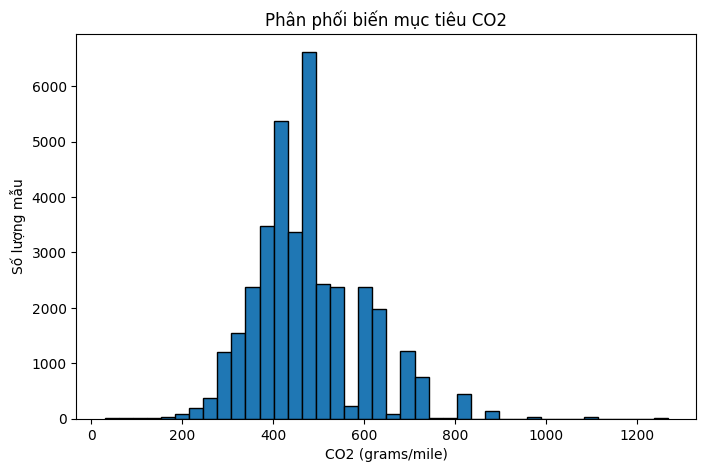

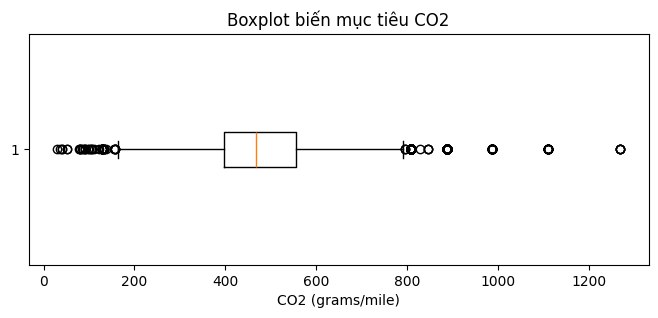

Thống kê biến mục tiêu CO2:


,tailpipe_co2_in_grams_mile_ft1
count,36794.000000
mean,475.580844
std,119.124057
min,29.000000
25%,397.000000
50%,467.736842
75%,555.437500
max,1269.571429


In [ ]:
# Trực quan hóa phân phối biến mục tiêu CO2
plt.figure(figsize=(8, 5))
plt.hist(df_model_clean[target], bins=40, edgecolor="black")
plt.xlabel("CO2 (grams/mile)")
plt.ylabel("Số lượng mẫu")
plt.title("Phân phối biến mục tiêu CO2")
plt.show()

plt.figure(figsize=(8, 3))
plt.boxplot(df_model_clean[target], vert=False)
plt.xlabel("CO2 (grams/mile)")
plt.title("Boxplot biến mục tiêu CO2")
plt.show()

print("Thống kê biến mục tiêu CO2:")
display(df_model_clean[target].describe())

In [ ]:
# Kiểm tra ngoại lai theo phương pháp IQR cho các biến số
numeric_features_for_outlier = df_model_clean[candidate_features].select_dtypes(include=["int64", "float64"]).columns.tolist()

outlier_summary = []
for col in numeric_features_for_outlier:
    q1 = df_model_clean[col].quantile(0.25)
    q3 = df_model_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df_model_clean[col] < lower_bound) | (df_model_clean[col] > upper_bound)).sum()
    outlier_rate = outlier_count / len(df_model_clean) * 100

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_bound": lower_bound,
        "Upper_bound": upper_bound,
        "Outlier_count": outlier_count,
        "Outlier_rate_%": outlier_rate
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(by="Outlier_rate_%", ascending=False)

print("Bảng thống kê ngoại lai của các biến số:")
display(outlier_summary)


Bảng thống kê ngoại lai của các biến số:


,Feature,Q1,Q3,IQR,Lower_bound,Upper_bound,Outlier_count,Outlier_rate_%
4,x2d_passenger_volume,0.0,0.0,0.0,0.00,0.00,5835,15.858564
5,x2d_luggage_volume,0.0,0.0,0.0,0.00,0.00,5834,15.855846
9,hatchback_luggage_volume,0.0,0.0,0.0,0.00,0.00,4190,11.387726
8,hatchback_passenger_volume,0.0,0.0,0.0,0.00,0.00,4189,11.385008
7,x4d_luggage_volume,0.0,13.0,13.0,-19.50,32.50,1170,3.179866
1,engine_cylinders,4.0,6.0,2.0,1.00,9.00,732,1.989455
3,save_or_spend_5_year,-5000.0,-1250.0,3750.0,-10625.00,4375.00,586,1.592651
10,hours_to_charge_240v,0.0,0.0,0.0,0.00,0.00,65,0.176659
2,engine_displacement,2.2,4.3,2.1,-0.95,7.45,43,0.116867
0,year,1991.0,2010.0,19.0,1962.50,2038.50,0,0.000000


**NX bảng giá trị ngoại lai**

Bảng thống kê ngoại lai cho thấy một số biến có tỷ lệ ngoại lai khá cao như *x2d_passenger_volume*, *x2d_luggage_volume*, *hatchback_luggage_volume*. Tuy nhiên, các biến này có Q1 và Q3 đều bằng 0, chứng tỏ phần lớn dữ liệu bằng 0 do đặc thù loại xe. Vì vậy, các giá trị khác 0 bị IQR đánh dấu là ngoại lai nhưng chưa chắc là dữ liệu sai. Với các biến như engine_cylinders, *engine_displacement*, *save_or_spend_5_year*, ngoại lai phản ánh các xe có đặc điểm đặc biệt như động cơ lớn, nhiều xi-lanh hoặc chi phí nhiên liệu khác biệt. Do đó, thay vì xóa toàn bộ ngoại lai, bài toán nên dùng phương pháp giới hạn giá trị biên như IQR Capping để giảm ảnh hưởng cực đoan nhưng vẫn giữ lại dữ liệu.

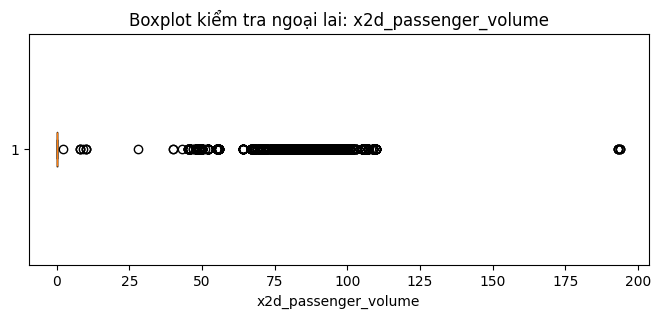

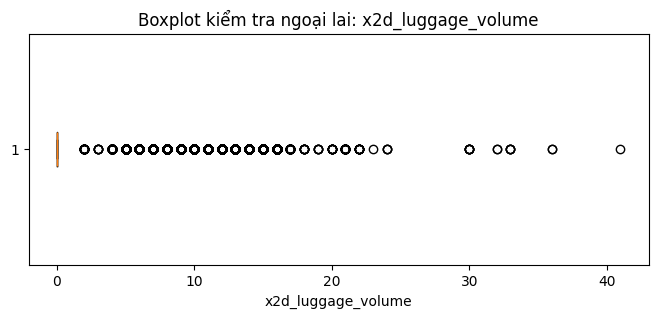

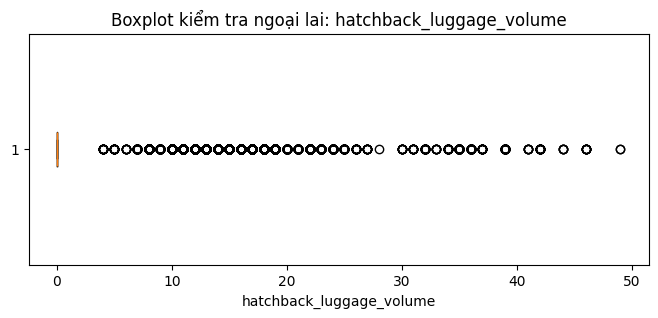

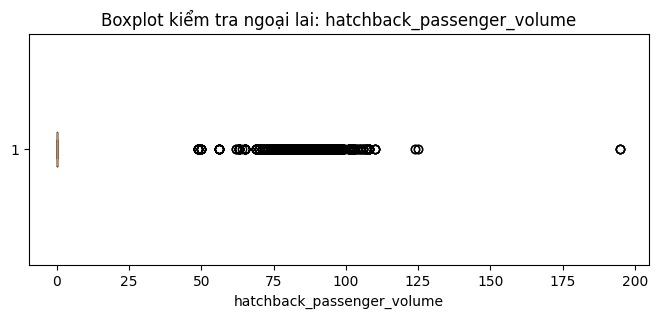

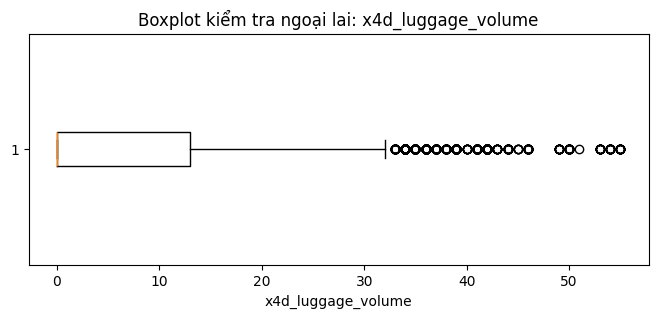

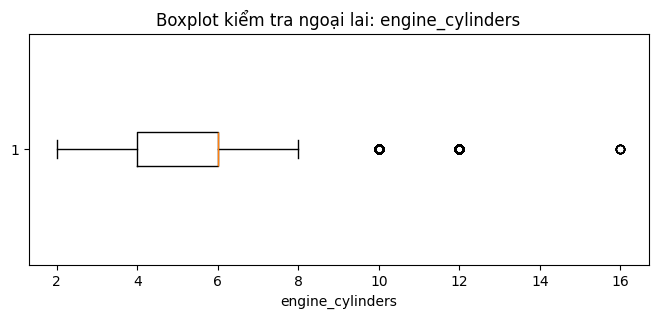

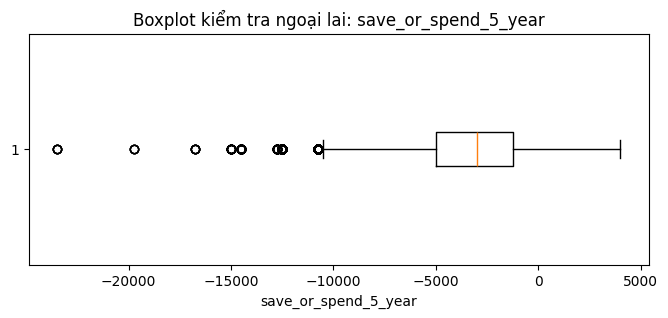

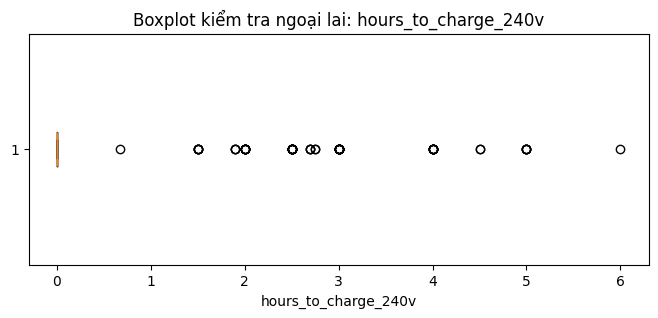

In [ ]:
# Vẽ boxplot cho các biến số có tỷ lệ ngoại lai cao nhất
TOP_N_OUTLIER_FEATURES = 8

top_outlier_features = outlier_summary.head(TOP_N_OUTLIER_FEATURES)["Feature"].tolist()

for col in top_outlier_features:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df_model_clean[col], vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot kiểm tra ngoại lai: {col}")
    plt.show()


Top biến số có tương quan cao với CO2 trước khi xử lý:


,tailpipe_co2_in_grams_mile_ft1
save_or_spend_5_year,0.938129
engine_displacement,0.801802
engine_cylinders,0.750473
x4d_passenger_volume,0.336061
hatchback_passenger_volume,0.288873
x4d_luggage_volume,0.281143
hatchback_luggage_volume,0.245750
year,0.226951


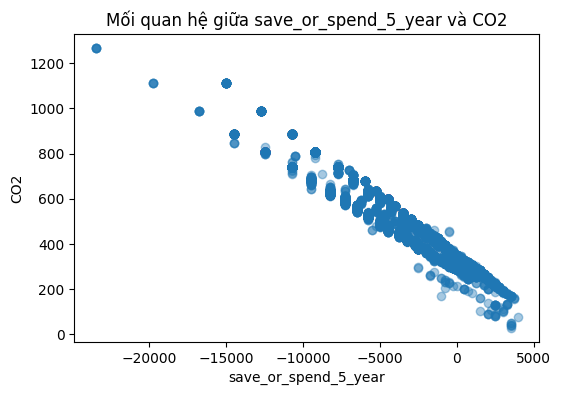

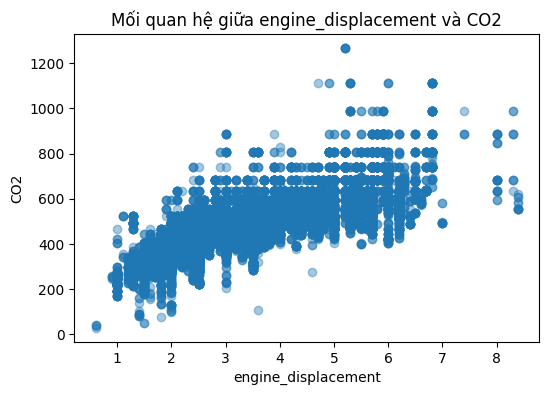

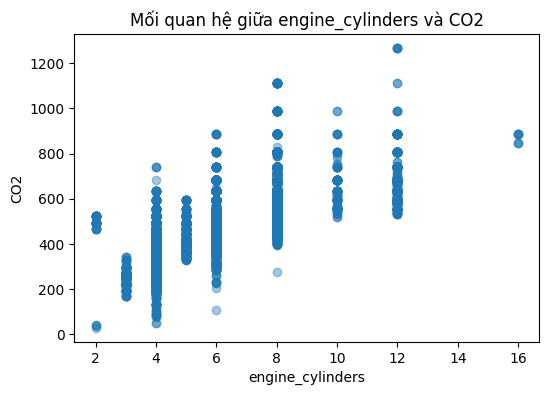

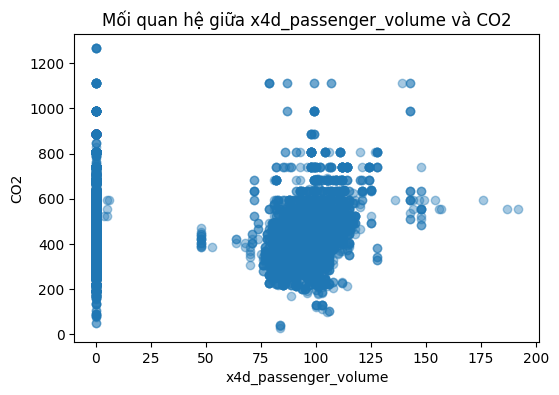

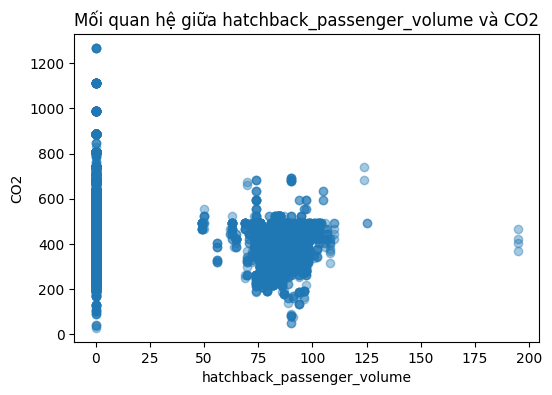

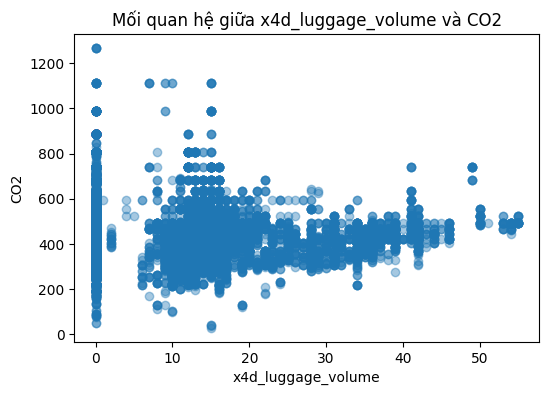

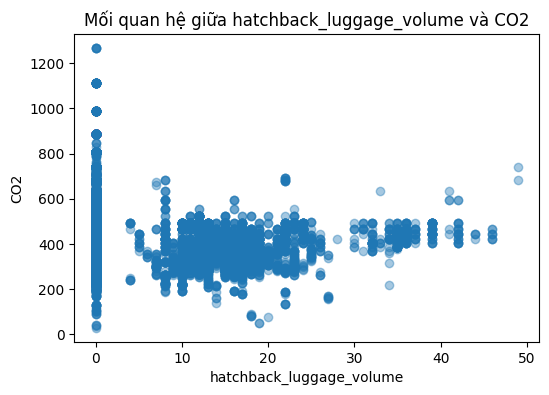

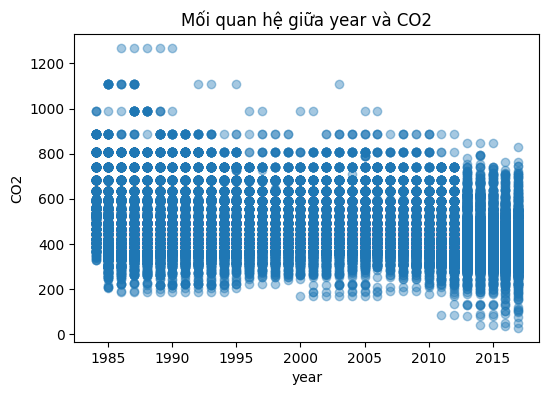

In [ ]:
# Trực quan hóa tương quan giữa một số biến số và CO2
# Chọn tối đa 8 biến số có tương quan tuyệt đối cao nhất với target để vẽ scatter
numeric_corr_cols = [col for col in numeric_features_for_outlier if col in df_model_clean.columns]

corr_with_target_before_train = df_model_clean[numeric_corr_cols + [target]].corr(numeric_only=True)[target]
corr_with_target_before_train = corr_with_target_before_train.drop(target).abs().sort_values(ascending=False)

top_corr_features = corr_with_target_before_train.head(8).index.tolist()

print("Top biến số có tương quan cao với CO2 trước khi xử lý:")
display(corr_with_target_before_train.head(8))

for col in top_corr_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_model_clean[col], df_model_clean[target], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("CO2")
    plt.title(f"Mối quan hệ giữa {col} và CO2")
    plt.show()


In [ ]:
#chia dữ liệu
X_all = df_model_clean[candidate_features]
y = df_model_clean[target]

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.3,
    random_state=42
)

print("X_train_all:", X_train_all.shape)
print("X_test_all:", X_test_all.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_all: (25755, 17)
X_test_all: (11039, 17)
y_train: (25755,)
y_test: (11039,)


In [ ]:
#kiểm tra tương quan
HIGH_CORR_THRESHOLD = 0.9

numeric_train_cols = X_train_all.select_dtypes(include=["int64", "float64"]).columns.tolist()

corr_train = pd.concat(
    [X_train_all[numeric_train_cols], y_train.rename(target)],
    axis=1
).corr(numeric_only=True)[target]

corr_train = corr_train.drop(target).abs().sort_values(ascending=False)

print("Tương quan tuyệt đối với target trên tập train:")
display(corr_train)

high_corr_cols = corr_train[corr_train >= HIGH_CORR_THRESHOLD].index.tolist()

print("Các cột bị loại vì tương quan quá cao với target:")
print(high_corr_cols)

candidate_features = [
    col for col in candidate_features
    if col not in high_corr_cols
]

X_train_all = X_train_all[candidate_features].copy()
X_test_all = X_test_all[candidate_features].copy()

print("Số cột còn lại sau khi loại tương quan quá cao:", len(candidate_features))
print("X_train_all sau lọc tương quan:", X_train_all.shape)
print("X_test_all sau lọc tương quan:", X_test_all.shape)

Tương quan tuyệt đối với target trên tập train:


,tailpipe_co2_in_grams_mile_ft1
save_or_spend_5_year,0.937540
engine_displacement,0.801924
engine_cylinders,0.750813
x4d_passenger_volume,0.334055
hatchback_passenger_volume,0.285811
x4d_luggage_volume,0.278588
hatchback_luggage_volume,0.241091
year,0.225485
x2d_luggage_volume,0.141478
x2d_passenger_volume,0.137581


Các cột bị loại vì tương quan quá cao với target:
['save_or_spend_5_year']
Số cột còn lại sau khi loại tương quan quá cao: 16
X_train_all sau lọc tương quan: (25755, 16)
X_test_all sau lọc tương quan: (11039, 16)


In [ ]:
ZERO_THRESHOLD = 70

zero_rate = (X_train_all == 0).mean() * 100

zero_table = pd.DataFrame({
    "Tỷ lệ 0 (%)": zero_rate
}).sort_values(by="Tỷ lệ 0 (%)", ascending=False)

display(zero_table)

valid_features = zero_rate[zero_rate <= ZERO_THRESHOLD].index.tolist()

X_train_all = X_train_all[valid_features].copy()
X_test_all = X_test_all[valid_features].copy()

print("Số cột hợp lệ sau khi loại cột nhiều 0:", len(valid_features))
print("X_train_all:", X_train_all.shape)
print("X_test_all:", X_test_all.shape)

,Tỷ lệ 0 (%)
hours_to_charge_ac_240v,100.000000
hours_to_charge_240v,99.825277
hatchback_passenger_volume,88.479907
hatchback_luggage_volume,88.476024
x2d_luggage_volume,83.952631
x2d_passenger_volume,83.948748
x4d_luggage_volume,65.435838
x4d_passenger_volume,65.435838
engine_cylinders,0.000000
year,0.000000


Số cột hợp lệ sau khi loại cột nhiều 0: 10
X_train_all: (25755, 10)
X_test_all: (11039, 10)


In [ ]:
X_train_encoded = X_train_all.copy()
X_test_encoded = X_test_all.copy()

numeric_cols = X_train_encoded.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train_encoded.select_dtypes(include=["object"]).columns.tolist()

print("Số cột số sau lọc:", len(numeric_cols))
print("Số cột chữ sau lọc:", len(categorical_cols))

# Điền thiếu cột số bằng median của train
for col in numeric_cols:
    median_value = X_train_encoded[col].median()
    X_train_encoded[col] = X_train_encoded[col].fillna(median_value)
    X_test_encoded[col] = X_test_encoded[col].fillna(median_value)

# Điền thiếu cột chữ bằng mode của train
for col in categorical_cols:
    mode_value = X_train_encoded[col].mode(dropna=True)
    fill_value = mode_value.iloc[0] if len(mode_value) > 0 else "Unknown"

    X_train_encoded[col] = X_train_encoded[col].fillna(fill_value).astype(str)
    X_test_encoded[col] = X_test_encoded[col].fillna(fill_value).astype(str)

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

if len(categorical_cols) > 0:
    X_train_encoded[categorical_cols] = encoder.fit_transform(X_train_encoded[categorical_cols])
    X_test_encoded[categorical_cols] = encoder.transform(X_test_encoded[categorical_cols])

print("Kích thước X_train_encoded:", X_train_encoded.shape)
print("Kích thước X_test_encoded:", X_test_encoded.shape)
#encoder chỉ fit trên tập train, sau đó transform tập test.

Số cột số sau lọc: 5
Số cột chữ sau lọc: 5
Kích thước X_train_encoded: (25755, 10)
Kích thước X_test_encoded: (11039, 10)


In [ ]:
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train_encoded, y_train)

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": rf_selector.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top cột quan trọng nhất:")
display(feature_importance.head(20))

Top cột quan trọng nhất:


,Feature,Importance
2,engine_displacement,0.734728
0,year,0.083916
6,class,0.047353
5,transmission,0.038660
1,engine_cylinders,0.026732
8,drive,0.024903
7,fuel_type,0.013083
3,x4d_passenger_volume,0.012556
4,x4d_luggage_volume,0.010570
9,fuel_type_1,0.007499


In [ ]:
selected_features = feature_importance.head(11)["Feature"].tolist()

print("Số cột input cuối cùng:")
for i, col in enumerate(selected_features, 1):
    print(f"{i}. {col}")

#print("Số cột input cuối:", len(selected_features))

Số cột input cuối cùng:
1. engine_displacement
2. year
3. class
4. transmission
5. engine_cylinders
6. drive
7. fuel_type
8. x4d_passenger_volume
9. x4d_luggage_volume
10. fuel_type_1


In [ ]:
X_train = X_train_encoded[selected_features].copy()
X_test = X_test_encoded[selected_features].copy()

print("Kích thước X_train cuối:", X_train.shape)
print("Kích thước X_test cuối:", X_test.shape)

df_final = pd.concat([
    pd.concat([X_train, X_test], axis=0),
    pd.concat([y_train, y_test], axis=0).rename(target)
], axis=1)

print("Số dòng sạch cuối:", df_final.shape[0])
print("Số cột cuối tính cả target:", df_final.shape[1])
print("Kích thước dữ liệu sạch cuối:", df_final.shape)

Kích thước X_train cuối: (25755, 10)
Kích thước X_test cuối: (11039, 10)
Số dòng sạch cuối: 36794
Số cột cuối tính cả target: 11
Kích thước dữ liệu sạch cuối: (36794, 11)


In [ ]:
# mô hình linearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 44.071419258383095
RMSE: 60.875347951585496
R2: 0.7473893814250046


In [ ]:
# tối ưu Linear Regression bằng GridSearchCV
linear_param_grid = {
    "fit_intercept": [True, False],
    "positive": [False, True]
}

linear_grid_search = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=linear_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

linear_grid_search.fit(X_train, y_train)

print("Siêu tham số tốt nhất của Linear Regression:")
print(linear_grid_search.best_params_)
print("RMSE tốt nhất trong cross-validation:", -linear_grid_search.best_score_)

best_lr_model = linear_grid_search.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(X_test)

mae_lr_tuned = mean_absolute_error(y_test, y_pred_lr_tuned)
rmse_lr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_lr_tuned))
r2_lr_tuned = r2_score(y_test, y_pred_lr_tuned)

print("Linear Regression sau khi tối ưu siêu tham số")
print("MAE:", mae_lr_tuned)
print("RMSE:", rmse_lr_tuned)
print("R2:", r2_lr_tuned)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Siêu tham số tốt nhất của Linear Regression:
{'fit_intercept': True, 'positive': False}
RMSE tốt nhất trong cross-validation: 59.05888729080278
Linear Regression sau khi tối ưu siêu tham số
MAE: 44.071419258383095
RMSE: 60.875347951585496
R2: 0.7473893814250046


In [ ]:
#mô hình random forest
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


#tối ưu bằng gridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Siêu tham số tốt nhất:")
print(grid_search.best_params_)

print("RMSE tốt nhất trong cross-validation:", -grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Siêu tham số tốt nhất:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
RMSE tốt nhất trong cross-validation: 29.746996358559603


In [ ]:
best_rf_model = grid_search.best_estimator_
best_rf_model.fit(X_train, y_train)

y_pred_rf = best_rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest sau khi tối ưu siêu tham số")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest sau khi tối ưu siêu tham số
MAE: 16.48497014417377
RMSE: 26.944686694275905
R2: 0.9505102835685462


In [ ]:
#so sánh
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Tuned"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2": [
        r2_lr,
        r2_rf
    ]
})

display(results)

,Model,MAE,RMSE,R2
0,Linear Regression,44.071419,60.875348,0.747389
1,Random Forest Tuned,16.484970,26.944687,0.950510


In [ ]:
best_model = results.sort_values(by="RMSE").iloc[0]

print("Mô hình tốt nhất theo RMSE:", best_model["Model"])
print("RMSE tốt nhất:", best_model["RMSE"])
print("R2 tương ứng:", best_model["R2"])

Mô hình tốt nhất theo RMSE: Random Forest Tuned
RMSE tốt nhất: 26.944686694275905
R2 tương ứng: 0.9505102835685462


In [ ]:
y_train_pred_rf = best_rf_model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse = rmse_rf

train_r2 = r2_score(y_train, y_train_pred_rf)
test_r2 = r2_rf

print("Kiểm tra overfitting Random Forest")
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

if train_r2 - test_r2 > 0.1:
    print("Mô hình có dấu hiệu overfitting.")
else:
    print("Mô hình chưa có dấu hiệu overfitting rõ ràng.")

Kiểm tra overfitting Random Forest
Train RMSE: 15.870073644191097
Test RMSE: 26.944686694275905
Train R2: 0.9819878223300965
Test R2: 0.9505102835685462
Mô hình chưa có dấu hiệu overfitting rõ ràng.


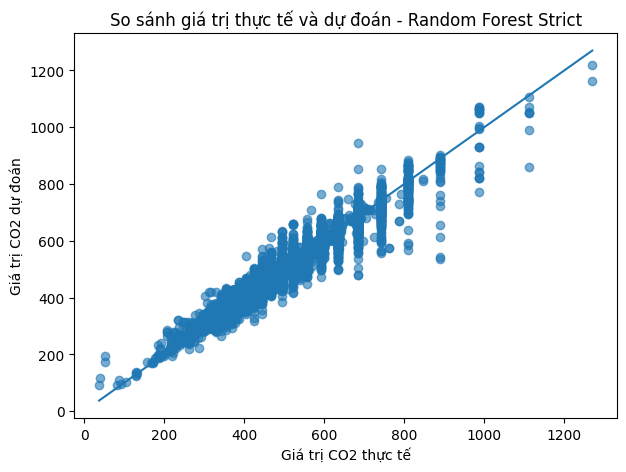

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.6)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Giá trị CO2 thực tế")
plt.ylabel("Giá trị CO2 dự đoán")
plt.title("So sánh giá trị thực tế và dự đoán - Random Forest Strict")
plt.show()

In [ ]:
#test 5 mẫu ngẫu nhiên
sample_test = X_test.sample(5)
y_true = y_test.loc[sample_test.index]
y_pred = best_rf_model.predict(sample_test)

result_sample = sample_test.copy()
result_sample["CO2 thực tế"] = y_true.values
result_sample["CO2 dự đoán"] = y_pred
result_sample["Sai số tuyệt đối"] = abs(y_true.values - y_pred)

display(result_sample)

,engine_displacement,year,class,transmission,engine_cylinders,drive,fuel_type,x4d_passenger_volume,x4d_luggage_volume,fuel_type_1,CO2 thực tế,CO2 dự đoán,Sai số tuyệt đối
18192,3.2,2001,2.0,31.0,6.0,6.0,6.0,95,15,3.0,423.190476,431.708003,8.517527
24108,2.9,2007,23.0,30.0,4.0,6.0,10.0,0,0,4.0,493.722222,493.364637,0.357585
19013,3.2,2002,21.0,30.0,6.0,2.0,10.0,0,0,4.0,555.437500,549.327211,6.110289
22810,2.4,2005,13.0,23.0,5.0,4.0,6.0,0,0,3.0,403.954545,421.938380,17.983834
24231,1.8,2007,13.0,40.0,4.0,4.0,10.0,0,0,4.0,341.807692,329.005593,12.802099
